In [3]:
import librosa
import librosa.display
import os
from pydub import AudioSegment
import matplotlib.pyplot as plt
import numpy as np

In [11]:
audio_file_src = r'./audio.mp3'
samples, sample_rate = librosa.load(audio_file_src)

/home/vatssv/anaconda3/lib/python3.8/site-packages/librosa/util/decorators.py:88: UserWarning: PySoundFile failed. Trying audioread instead.
  return f(*args, **kwargs)


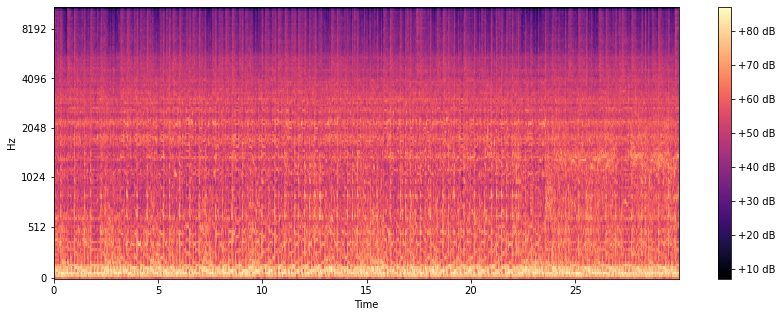

In [20]:
fig = plt.figure(figsize=(14, 5))
sgram = librosa.stft(samples)
sgram_mag, _ = librosa.magphase(sgram)
mel_scale = librosa.feature.melspectrogram(S=sgram_mag, sr=sample_rate)
mel_gram = librosa.amplitude_to_db(mel_scale, ref=np.min)
librosa.display.specshow(mel_gram, sr=sample_rate, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
fig.savefig(f'{Output_path}.png')

In [4]:
class save_spectrograms(object):
    def __init__(self, dir_path, output_dir):
        self.path = dir_path
        self.output_dir = output_dir

    def fetch_file_paths(self):
        self.files_list = []
        for root, dirs, files in os.walk(self.path):
            # print(f'Roots: {root}, Dirs: {dirs}, Files: {files}')
            if len(dirs) == 0:
                file_counter = 0
                for file in files:
                    if file_counter == 10:
                        break
                    self.files_list.append(os.path.join(root, file))
                    file_counter += 1
    
        return self.files_list

    def convert_to_spectrograms(self):

        for file in self.files_list:

            samples, sample_rate = librosa.load(file)
            fig = plt.figure(figsize=(14, 5))

            sgram = librosa.stft(samples)
            sgram_mag, _ = librosa.magphase(sgram)
            mel_scale = librosa.feature.melspectrogram(S=sgram_mag, sr=sample_rate)
            mel_gram = librosa.amplitude_to_db(mel_scale, ref=np.min)

            librosa.display.specshow(mel_gram, sr=sample_rate, x_axis='time', y_axis='mel')
            plt.colorbar(format='%+2.0f dB')

            base = os.path.basename(file)
            base = os.path.splitext(base)[0]

            file_dir = file.split('/')[-2]

            fig.savefig(f'{self.output_dir}{file_dir}_{base}.png')

In [ ]:
spects = save_spectrograms('/mnt/f/Code/Music_Dataset/fma_small/fma_small/', '/mnt/f/Code/Music_Dataset/Spectrograms/')
spects.fetch_file_paths()
print('File paths: ', spects.fetch_file_paths())
spects.convert_to_spectrograms()